# **Atividade Prática**
<font size=3>

- **Tema:** Problema de busca.
- **Prazo de entrega:** 15 de Setembro.

---

## **Enunciado:**
<font size=3>
    
Baseado no **_notebook_ 3.2** ("Exemplo de Busca em Largura"), desenvolva duas soluções para encontrar uma rota em um mapa: uma com um algoritmo de **busca desinformada** e outra com um de **busca informada**.

In [1]:
#from google.colab import drive
#drive.mount('/content/drive/')

---

### **1. Questão — Busca Desinformada:**
#### **1.1 Implementação:**
<font size=3>

- Escolha um algoritmo de **busca desinformada** (que não seja *Busca em Largura*);

- Defina as coordenadas de origem e destino (*no Google Maps, ao clinar em uma posição no mapa com o botão direito, as coordenadas aparecem em um aba*);

- Defina o modo de percurso ("*drive*", "*walk*", "*bike*" ou "*all*");

- Execute a busca, **imprima na tela** as ruas do caminho encontrado e faça o **plote do mapa**.


In [ ]:
%pip install osmnx
%pip install matplotlib
%pip install scikit-learn

In [157]:
import osmnx as ox
import numpy as np
import heapq
import matplotlib.pyplot as plt
from networkx import MultiDiGraph
from collections import deque

In [154]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371000.0
    p1 = np.deg2rad(lat1)
    p2 = np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dl   = np.deg2rad(lon2 - lon1)

    a = np.sin(dphi/2.0)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2.0)**2

    return 2*R*np.arcsin(np.sqrt(a))


def graph(lat_o, lon_o, lat_d, lon_d, mode = "walk", margin = 500):

    """
    Baixa um grafo OSM que cobre a área entre origem e destino, com margem extra.
    mode: 'drive' | 'walk' | 'bike' | 'all'
    """

    dist = haversine(lat_o, lon_o, lat_d, lon_d) + margin

    lat_c = (lat_o + lat_d)/2
    lon_c = (lon_o + lon_d)/2

    return ox.graph_from_point(center_point = (lat_c, lon_c), dist = dist, network_type = mode, simplify = True)


def edges2streets(G, path_nodes):

    streets = []
    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        data_options = G.get_edge_data(u, v)

        if not data_options: # mão oposta, se necessário
            data_options = G.get_edge_data(v, u)
        if not data_options:
            streets.append("(desconhecida)")
            continue

        data = list(data_options.values())[0]
        name = data.get('name')

        if isinstance(name, list) and name:
            streets.append(name[0])
        elif isinstance(name, str) and name.strip():
            streets.append(name)
        else:
            streets.append("(sem nome)")

    return streets

In [155]:
class Problem1:

    def __init__(self, initial_state, actions, transition_model, goal_test, step_cost):

        self.initial_state = initial_state
        self.actions = actions                    # função actions(state) -> iterável de actions
        self.transition_model = transition_model  # função (state, action) -> new_state
        self.goal_test = goal_test                # função (state) -> bool
        self.step_cost = step_cost                # função (state, action) -> custo

class Node1:

    def __init__(self, problem, parent = None, action = None, state = None):

        self.parent = parent
        self.action = action

        if parent is None:
            self.state = state
            self.path_cost = 0.0
        else:
            self.state = problem.transition_model(parent.state, action)
            self.path_cost = parent.path_cost + problem.step_cost(parent.state, action)


    def __eq__(self, other):

        return isinstance(other, Node1) and self.state == other.state


    def __hash__(self):

        return hash(self.state)


In [156]:
class BidirectionalSearch:

    """
    Duas BFS simultâneas (start e goal). Ao encontrar um estado comum, 'costura' as metades
    e retorna um Node meta cuja cadeia de 'parent' reconstrói start -> ... -> goal (como no BFS).
    """

    def __init__(self, problem, goal_state):

        self.problem = problem
        self.goal_state = goal_state

        self.frontier_start = deque()
        self.explored_start = {}
        self.frontier_goal = deque()
        self.explored_goal = {}


    def search(self):

        root_start = Node1(self.problem, state = self.problem.initial_state)
        root_goal = Node1(self.problem, state = self.goal_state)

        if root_start.state == root_goal.state:
            return [root_start.state]

        self.frontier_start.append(root_start)
        self.explored_start[root_start.state] = root_start
        self.frontier_goal.append(root_goal)
        self.explored_goal[root_goal.state] = root_goal

        while self.frontier_start and self.frontier_goal:

            # expande a fronteira menor para otimizar o encontro:
            if len(self.frontier_start) <= len(self.frontier_goal):
                meet_node = self._expand_one_step(is_forward = True)
            else:
                meet_node = self._expand_one_step(is_forward = False)

            if meet_node:
                return self._reconstruct_path(meet_node['start'], meet_node['goal'])

        return None


    def _expand_one_step(self, is_forward):

        if is_forward:
            frontier, explored, other_explored = self.frontier_start, self.explored_start, self.explored_goal
        else:
            frontier, explored, other_explored = self.frontier_goal, self.explored_goal, self.explored_start

        if not frontier:
            return None

        node = frontier.popleft()

        # expande nó:
        for action in self.problem.actions(node.state, is_forward = is_forward):
            child = Node1(self.problem, node, action)

            if child.state not in explored:
                if child.state in other_explored:
                    if is_forward:
                        return {'start':child, 'goal':other_explored[child.state]}
                    else:
                        return {'start':other_explored[child.state], 'goal':child}

                frontier.append(child)
                explored[child.state] = child

        return None


    def _reconstruct_path(self, node_start, node_goal):

        path = []
        node = node_start

        while node:
            path.append(node.state)
            node = node.parent

        path.reverse()

        node = node_goal.parent

        while node:
            path.append(node.state)
            node = node.parent

        return path


In [158]:
class MapProblem(Problem1):

    """
    Estados = IDs de nós do grafo OSMNX (NetworkX).
    Ações(state) = nós vizinhos alcançáveis por uma aresta (sucessores).
    Modelo de transição(state, action) = action (vizinho escolhido).
    Custo de passo = 1 (BFS -> menor nº de arestas).
    """

    def __init__(self, G: MultiDiGraph, start_node, goal_node):

        self.G = G
        self.goal_node = goal_node

        super().__init__(initial_state = start_node,
                         actions = self.actions_fn,
                         transition_model = self.transition_fn,
                         goal_test = self.goal_test_fn,
                         step_cost = self.step_cost_fn)


    def actions_fn(self, state, is_forward = True):
        if is_forward:
            return self.G.successors(state) if hasattr(self.G, "successors") else self.G.neighbors(state)
        else:
            return self.G.predecessors(state) if hasattr(self.G, "predecessors") else self.G.neighbors(state)


    def transition_fn(self, state, action):
        return action


    def goal_test_fn(self, state):
        return state == self.goal_node


    def step_cost_fn(self, state, action, uniform_cost = False):

        if uniform_cost:
            return 1.0

        else:
            edge = self.G.get_edge_data(state, action)
            if not edge:
                edge = self.G.get_edge_data(action, state)
            return edge[0]['length']

In [159]:
# definindo o grafo da região:
lat_origin, lon_origin = -5.7842539491146345, -35.313161414434596
lat_goal, lon_goal = -5.832045868188761, -35.20547959029296
mode = "drive"  # 'drive' | 'walk' | 'bike' | 'all'

G = graph(lat_origin, lon_origin, lat_goal, lon_goal, mode = mode, margin = 600)

# definindo os nós mais próximos das coordenadas:
start = ox.nearest_nodes(G, lon_origin, lat_origin)
goal  = ox.nearest_nodes(G, lon_goal, lat_goal)

print("Start node ID:", start)
print("Goal node ID:", goal)

Start node ID: 4783745048
Goal node ID: 505103991


In [160]:
# definindo o problema de busca:
problem = MapProblem(G, start_node = start, goal_node = goal)

# definindo o modelo de busca:
bds = BidirectionalSearch(problem, goal)

# inicializando a busca:
path_nodes = bds.search()

In [161]:
# imprimindo o nome das ruas da rota:
print(f"# Nós no caminho (UCS): {len(path_nodes)}  |  # arestas: {len(path_nodes)-1}")
seq_ruas = edges2streets(G, path_nodes)

print("Ruas percorridas (aproximadamente):\n")
for i, r in enumerate(seq_ruas, 1):
    print(f"{i:02d}. {r}")

# Nós no caminho (UCS): 149  |  # arestas: 148
Ruas percorridas (aproximadamente):

01. Rua Renato Leitão de Almeida
02. Rua Brasil
03. Rua Bahia
04. Rua 7
05. Rua 22
06. Rua 22
07. Rua 22
08. Rua 22
09. Rua Engenheiro Roberto Bezerra Freire
10. (sem nome)
11. (sem nome)
12. (sem nome)
13. (sem nome)
14. (sem nome)
15. (sem nome)
16. (sem nome)
17. (sem nome)
18. (sem nome)
19. Avenida Firmino Moura
20. Rua Pedro Miranda da Silva
21. Rua Pedro Miranda da Silva
22. Rua Pedro Miranda da Silva
23. Rua Pedro Miranda da Silva
24. Rua Vereador Aldo Mendes da Silva
25. Rua Olinto José Rodrigues
26. (sem nome)
27. Rua Alexandre Cavalcante
28. Rua Pedro de Alcantara Cavalcanti
29. Rua Pedro de Alcantara Cavalcanti
30. Rua Vereador Eri Teixeira Dantas
31. Rua Manoel Ferreira Gomes
32. Rua Manoel Ferreira Gomes
33. Rua Gonçalo Pinheiro
34. Rua Gonçalo Pinheiro
35. Rua Geraldo Cassemiro
36. Rua Geraldo Cassemiro
37. Rua Geraldo Cassemiro
38. Rua José Horácio de Góis
39. Rua José Horácio de Góis
40

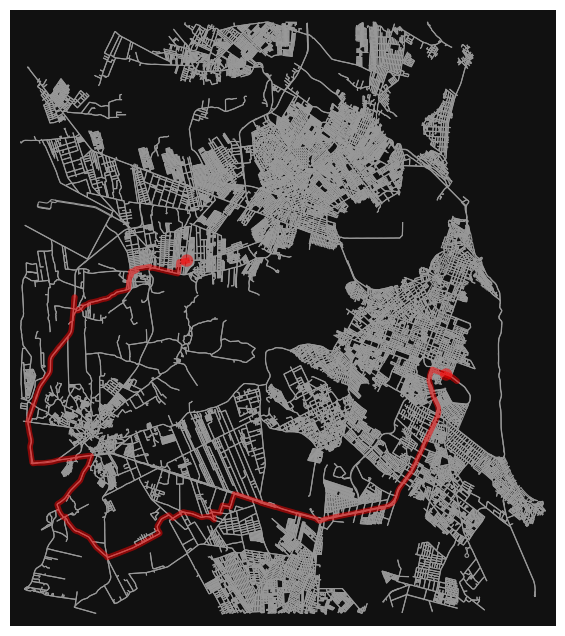

In [162]:
# plotando o mapa e rota de solução:

fig, ax = ox.plot_graph(G, show = False, close = False, node_size = 0, edge_linewidth = 0.8)
ox.plot_graph_route(G, path_nodes, ax = ax, route_linewidth = 4, orig_dest_size = 80, show = False, close = False)
plt.show()


### DiGraph Problem
to do

In [166]:
# definindo o grafo da região:
lat_origin, lon_origin = -5.7842539491146345, -35.313161414434596
lat_goal, lon_goal = -5.832045868188761, -35.20547959029296
mode = "drive"  # 'drive' | 'walk' | 'bike' | 'all'

G = graph(lat_origin, lon_origin, lat_goal, lon_goal, mode = mode, margin = 600).to_undirected()

# definindo os nós mais próximos das coordenadas:
start = ox.nearest_nodes(G, lon_origin, lat_origin)
goal  = ox.nearest_nodes(G, lon_goal, lat_goal)

print("Start node ID:", start)
print("Goal node ID:", goal)

Start node ID: 4783745048
Goal node ID: 505103991


In [167]:
# definindo o problema de busca:
problem = MapProblem(G, start_node = start, goal_node = goal)

# definindo o modelo de busca:
bds = BidirectionalSearch(problem, goal)

# inicializando a busca:
path_nodes = bds.search()

In [168]:
# imprimindo o nome das ruas da rota:
print(f"# Nós no caminho (UCS): {len(path_nodes)}  |  # arestas: {len(path_nodes)-1}")
seq_ruas = edges2streets(G, path_nodes)

print("Ruas percorridas (aproximadamente):\n")
for i, r in enumerate(seq_ruas, 1):
    print(f"{i:02d}. {r}")

# Nós no caminho (UCS): 125  |  # arestas: 124
Ruas percorridas (aproximadamente):

01. Rua Odilon Borges da Silva
02. Rua Corisco
03. Rua Corisco
04. Avenida Campos de Bagatelle
05. Rua Emanoel Hermógenes de Medeiros
06. Rua Major Nelson Varela Barca
07. Rua Major Nelson Varela Barca
08. Rua Major Nelson Varela Barca
09. Rua Major Nelson Varela Barca
10. Rua Vice-Presidente José Alencar Gomes da Silva
11. Rua Vice-Presidente José Alencar Gomes da Silva
12. Avenida João Dino Maia
13. Avenida João Dino Maia
14. Avenida João Dino Maia
15. Avenida João Dino Maia
16. Avenida João Dino Maia
17. Avenida João Dino Maia
18. Avenida João Dino Maia
19. Avenida João Dino Maia
20. Avenida João Dino Maia
21. Avenida João Dino Maia
22. Avenida João Dino Maia
23. Avenida João Dino Maia
24. Avenida João Dino Maia
25. Avenida Doutor Ruy Pereira dos Santos
26. Avenida Doutor Ruy Pereira dos Santos
27. Avenida Doutor Ruy Pereira dos Santos
28. Avenida Doutor Ruy Pereira dos Santos
29. Avenida Doutor Ruy 

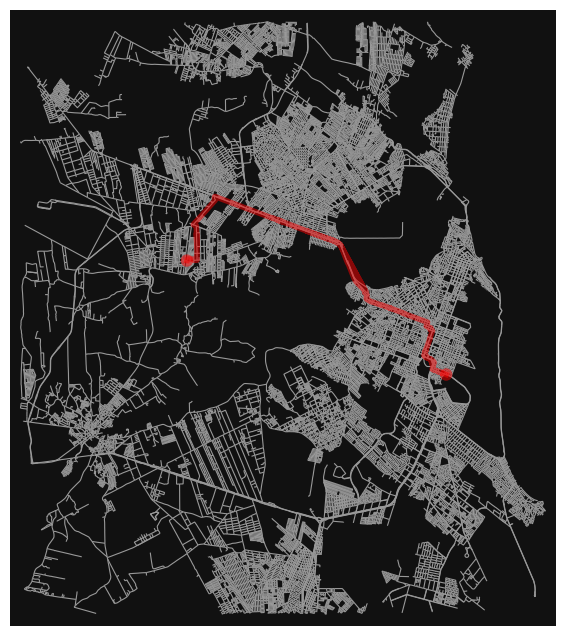

In [169]:
# plotando o mapa e rota de solução:

fig, ax = ox.plot_graph(G, show = False, close = False, node_size = 0, edge_linewidth = 0.8)
ox.plot_graph_route(G, path_nodes, ax = ax, route_linewidth = 4, orig_dest_size = 80, show = False, close = False)
plt.show()


#### **1.2 Análise:**
<font size=3>
    
Em uma **célula de markdown** compare o algoritmo que você escolheu com a **Busca em Largura (BFS)**, analisando os seguintes critérios:

- **Estrutura da Fronteira:** Qual estrutura de dados a fronteira utiliza (ex: Fila FIFO, Pilha LIFO, Fila de Prioridades)?

- **Otimalidade:** O seu algoritmo **garante** que a rota encontrada é a mais curta (com o menor número de ruas)? Justifique.

- **Complexidade:** Em geral, qual dos dois algoritmos (o seu ou o BFS) você espera que use mais memória para este problema de mapa? Por quê?
  

---

### **2. Questão — Busca Informada:**
#### **2.1 Implementação:**
<font size=3>

- Escolha um algoritmo de **busca informada**;

- Defina as coordenadas de origem e destino (diferença das usadas na **questão 1**);

- Defina o modo de percurso (diferença do usado na **questão 1**);

- Execute a busca, **imprima na tela** as ruas do caminho encontrado e faça o **plote do mapa**.


In [133]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371000.0
    p1 = np.deg2rad(lat1)
    p2 = np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dl   = np.deg2rad(lon2 - lon1)

    a = np.sin(dphi/2.0)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2.0)**2

    return 2*R*np.arcsin(np.sqrt(a))


def graph(lat_o, lon_o, lat_d, lon_d, mode = "walk", margin = 500):

    """
    Baixa um grafo OSM que cobre a área entre origem e destino, com margem extra.
    mode: 'drive' | 'walk' | 'bike' | 'all'
    """

    dist = haversine(lat_o, lon_o, lat_d, lon_d) + margin

    lat_c = (lat_o + lat_d)/2
    lon_c = (lon_o + lon_d)/2

    return ox.graph_from_point(center_point = (lat_c, lon_c), dist = dist, network_type = mode, simplify = True)


def edges2streets(G, path_nodes):

    streets = []
    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        data_options = G.get_edge_data(u, v)

        if not data_options: # mão oposta, se necessário
            data_options = G.get_edge_data(v, u)
        if not data_options:
            streets.append("(desconhecida)")
            continue

        data = list(data_options.values())[0]
        name = data.get('name')

        if isinstance(name, list) and name:
            streets.append(name[0])
        elif isinstance(name, str) and name.strip():
            streets.append(name)
        else:
            streets.append("(sem nome)")

    return streets

In [134]:
class Problem2:

    def __init__(self, initial_state, actions, transition_model, goal_test, step_cost):

        self.initial_state = initial_state
        self.actions = actions                    # função actions(state) -> iterável de actions
        self.transition_model = transition_model  # função (state, action) -> new_state
        self.goal_test = goal_test                # função (state) -> bool
        self.step_cost = step_cost                # função (state, action) -> custo

class Node2:

    def __init__(self, problem, parent = None, action = None):

        self.parent = parent
        self.action = action

        if parent is None:
            self.state = problem.initial_state
            self.path_cost = 0.0
        else:
            self.state = problem.transition_model(parent.state, action)
            self.path_cost = parent.path_cost + problem.step_cost(parent.state, action)


    def __eq__(self, other):

        return isinstance(other, Node) and self.state == other.state


    def __hash__(self):

        return hash(self.state)

In [135]:
class Node4Heap(Node2):

    def __init__(self, problem, parent = None, action = None):
        super().__init__(problem, parent, action)

    def __lt__(self, other):

        return self.path_cost < other.path_cost

In [136]:
class Heuristic:

    def __init__(self, graph, goal_state):

        self.G = graph
        self.goal = goal_state

    def __call__(self, state):

        node_coords = (self.G.nodes[state]['y'], self.G.nodes[state]['x'])
        goal_coords = (self.G.nodes[self.goal]['y'], self.G.nodes[self.goal]['x'])

        return haversine(node_coords[0], node_coords[1], goal_coords[0], goal_coords[1])

In [137]:
class AStarSearch:

    '''Método semelhante à Busca de Custo Uniforme.'''

    def __init__(self, problem, heuristic):

        self.problem = problem
        self.frontier = []
        self.explored = set()
        self.h = heuristic

    def search(self):

        root = Node4Heap(problem = self.problem)

        # A prioridade é f(n) = g(n) + h(n)
        # g(n) = root.path_cost (que é 0)
        # h(n) = self.h(root.state)

        priority = root.path_cost + self.h(root.state)
        heapq.heappush(self.frontier, (priority, root))

        while self.frontier:
            # removendo o nó com a menor prioridade - menor valor de f(n):
            priority, node = heapq.heappop(self.frontier)

            # se já exploramos este estado por um caminho melhor, ignoramos:
            if node.state in self.explored:
                continue

            if self.problem.goal_test(node.state):
                return node

            self.explored.add(node.state)

            # expansão do nó:
            for action in self.problem.actions(node.state):
                child = Node4Heap(self.problem, node, action)

                if child.state not in self.explored:
                    child_priority = child.path_cost + self.h(child.state)

                    heapq.heappush(self.frontier, (child_priority, child))

        return None # solução não encontrada


In [138]:
class MapProblem(Problem2):

    """
    Estados = IDs de nós do grafo OSMNX (NetworkX).
    Ações(state) = nós vizinhos alcançáveis por uma aresta (sucessores).
    Modelo de transição(state, action) = action (vizinho escolhido).
    Custo de passo = 1 (BFS -> menor nº de arestas).
    """

    def __init__(self, G, start_node, goal_node):

        self.G = G
        self.goal_node = goal_node

        super().__init__(initial_state = start_node,
                         actions = self.actions_fn,
                         transition_model = self.transition_fn,
                         goal_test = self.goal_test_fn,
                         step_cost = self.step_cost_fn)


    def actions_fn(self, state):

        return self.G.successors(state) if hasattr(self.G, "successors") else self.G.neighbors(state)


    def transition_fn(self, state, action):
        return action


    def goal_test_fn(self, state):
        return state == self.goal_node


    def step_cost_fn(self, state, action, uniform_cost = False):

        if uniform_cost:
            return 1.0

        else:
            edge = self.G.get_edge_data(state, action)
            return edge[0]['length']

In [139]:
# definindo o grafo da região:
lat_origin, lon_origin = -5.7842539491146345, -35.313161414434596
lat_goal, lon_goal = -5.832045868188761, -35.20547959029296
mode = "drive"  # 'drive' | 'walk' | 'bike' | 'all'

G = graph(lat_origin, lon_origin, lat_goal, lon_goal, mode = mode, margin = 600)

# definindo os nós mais próximos das coordenadas:
start = ox.nearest_nodes(G, lon_origin, lat_origin)
goal  = ox.nearest_nodes(G, lon_goal, lat_goal)

print("Start node ID:", start)
print("Goal node ID:", goal)

Start node ID: 4783745048
Goal node ID: 505103991


In [140]:
# definindo o problema de busca:
problem = MapProblem(G, start_node = start, goal_node = goal)

heuristic = Heuristic(G, goal)

# definindo o modelo de busca:
a_star_search = AStarSearch(problem, heuristic)

# inicializando a busca:
goal_node = a_star_search.search()

In [141]:
# extraindo o caminho de nós da solução da busca:
node = goal_node
path = []

while node is not None:
    path.append(node.state)
    node = node.parent

path_nodes = list(reversed(path))

print(f"# Nós no caminho (UCS): {len(path_nodes)}  |  # arestas: {len(path_nodes)-1}")

# Nós no caminho (UCS): 232  |  # arestas: 231


In [142]:
# imprimindo o nome das ruas da rota:
seq_ruas = edges2streets(G, path_nodes)

print("Ruas percorridas (aproximadamente):\n")
for i, r in enumerate(seq_ruas, 1):
    print(f"{i:02d}. {r}")

Ruas percorridas (aproximadamente):

01. Rua Odilon Borges da Silva
02. Rua Aeromot
03. Rua Aeromot
04. Avenida Campos de Bagatelle
05. Rua Emanoel Hermógenes de Medeiros
06. Rua Emanoel Hermógenes de Medeiros
07. Rua Emanoel Hermógenes de Medeiros
08. Rua Emanoel Hermógenes de Medeiros
09. Rua Emanoel Hermógenes de Medeiros
10. (sem nome)
11. Rua Antônio Oscar da Silva
12. Rua Terezinha de Jesus
13. Rua Terezinha de Jesus
14. Rua Maria Freire de Sá
15. (sem nome)
16. Rua Maria Freire de Sá
17. Rua Maria Freire de Sá
18. Rua Maria Freire de Sá
19. Rua Maria Freire de Sá
20. Rua Vereador Miguel Pontes
21. Rua Vereador Miguel Pontes
22. Rua Vereador Miguel Pontes
23. Rua Vereador Miguel Pontes
24. Rua Vereador Miguel Pontes
25. Rua Vereador Miguel Pontes
26. Rua Vereador Miguel Pontes
27. Rua Vereador Miguel Pontes
28. Rua Vereador Miguel Pontes
29. Rua Vereador Miguel Pontes
30. Rua Vereador Miguel Pontes
31. Rua Vereador Miguel Pontes
32. Rua Vereador Miguel Pontes
33. Avenida Cléa Mar

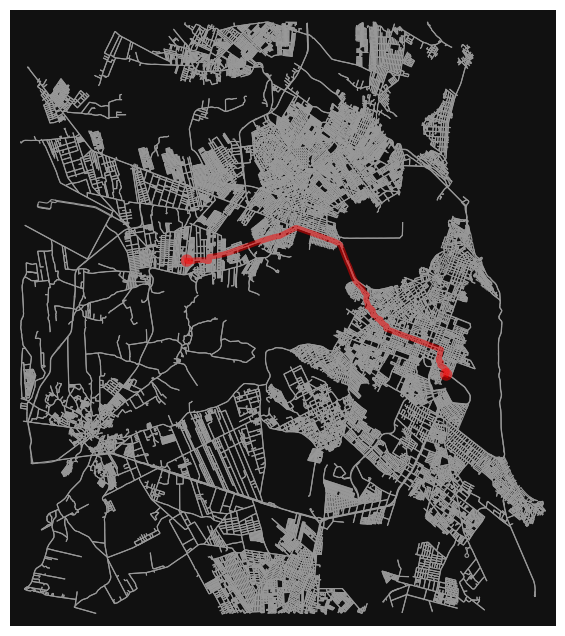

In [143]:
# plotando o mapa e rota de solução:

fig, ax = ox.plot_graph(G, show = False, close = False, node_size = 0, edge_linewidth = 0.8)
ox.plot_graph_route(G, path_nodes, ax = ax, route_linewidth = 4, orig_dest_size = 80, show = False, close = False)
plt.show()

#### **2.2 Análise:**
<font size=3>

Em uma **célula de markdown** descreva as principais características do algoritmo que você escolheu, respondendo:

- **Heurística:** Qual foi a função heurística `h(n)` que você utilizou para guiar a busca?

- **Função de Avaliação:** Como o seu algoritmo prioriza os nós na fronteira? Ele usa apenas a heurística $h(n)$, como a Busca Gananciosa, ou uma combinação de custo e heurística $f(n) = g(n) + h(n)$, como o A*?

- **Otimalidade:** A rota encontrada pelo seu algoritmo é **garantidamente** a de menor custo (menor distância total)? Explique como a sua escolha de heurística e função de avaliação afeta essa garantia.

  